### Setup

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
import pandas as pd


In [45]:
def quick_plot(func,x = None,y = None,yerr = None,label = None , title = None , x_title = None , 
               y_title = None, p0 = None,log = '.'):
    """
    Uses Scipy curve_fit to automatically create comparison plot and residual plot.
    MUST define func() before using function!
    Can take inf amount of function arguments!
    Stores Scipy Perr and popt
    """

    popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)

    perr = np.sqrt(np.diag(pcov))
    
    y_fit = func(x,*popt)
    
    print(*popt)
    print(*perr)

    plt.errorbar (x, y,fmt = 'o',yerr = yerr,label = label )
    plt.plot(x,y_fit)
    plt.title(title)
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.grid()
    plt.show()


    resid = y - y_fit

    plt.errorbar(x,resid,yerr = yerr, fmt = 'o',label = label)
    plt.axhline(y = 0, color = 'black', linestyle = '--')
    plt.grid()
    plt.legend()
    plt.xlabel(x_title)
    plt.ylabel(y_title)
    plt.title(title)
    plt.show()


### Test 1: Messing Around

1.0
inf


/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_45145/380527742.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(func,x,y,sigma = yerr, absolute_sigma = True, p0=p0)


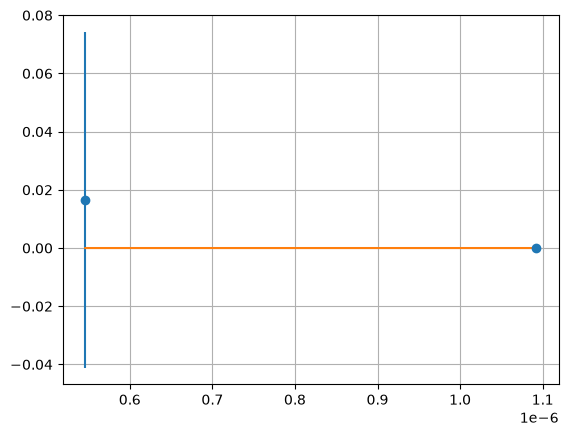

/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_45145/380527742.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


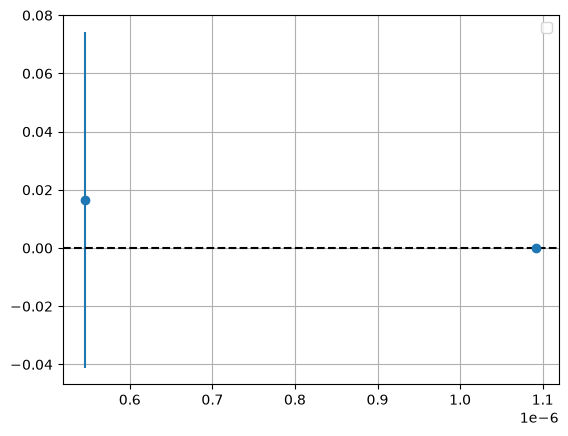

In [46]:
df_r = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_R.csv')
df_l = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_L.csv')
df_o = pd.read_csv(r'/Users/cadenjensen/Desktop/Phys 133/Speclab/data/PHYS 133_Atomic Spectra Lab_Data - Hg_M.csv')
#right dial 
theta_A_0 = df_o.iloc[:,1]
theta_B_0 = df_o.iloc[:,2]

theta_L_A = df_l.iloc[:2,1]
theta_L_B = df_l.iloc[:2,2]

theta_R_A = df_r.iloc[:2,1]
theta_R_B = df_r.iloc[:2,2]

#left dial
theta = 0.25 * (theta_L_A + theta_L_B + theta_R_A + theta_R_B - 2*(theta_A_0 + theta_B_0))

m = np.array([1,2])

sigma = np.sqrt(np.square(df_o.iloc[:2,3])+ 
                np.square(df_o.iloc[:2,4])+ 
                np.square(df_r.iloc[:2,3])+
                np.square(df_r.iloc[:2,4])+
                np.square(df_l.iloc[:2,3])+
                np.square(df_l.iloc[:2,4]))


wave = 546.074 *1e-9
x = m * wave
y = np.nan_to_num(np.sin(theta))

def func(x,d):
    return (x)/d

quick_plot(func, x,y,yerr = sigma )



3.5206190978584327e-06
7.458658146248766e-07


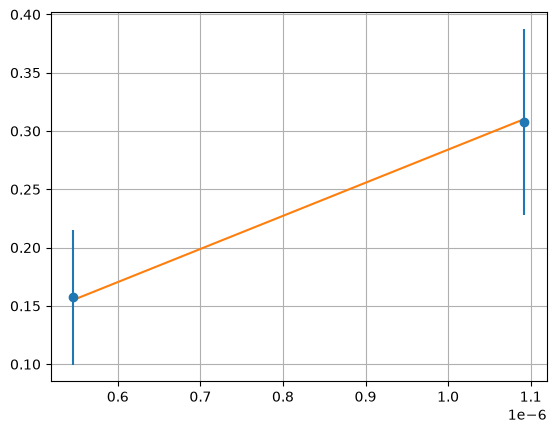

/var/folders/_c/5y50sbcs15x51qmpgmm2ftk00000gn/T/ipykernel_45145/380527742.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


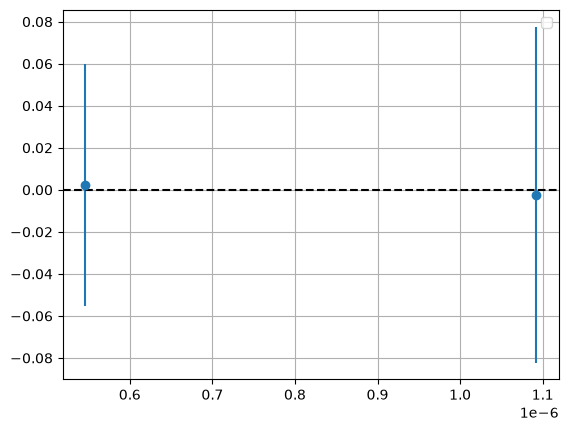

In [55]:
# 1. Consistently slice ALL data to the first 2 rows [:2] to avoid NaN mismatches
theta_A_0 = df_o.iloc[0, 1]
theta_B_0 = df_o.iloc[0, 2]
theta_L_A = df_l.iloc[:2, 1]
theta_L_B = df_l.iloc[:2, 2]
theta_R_A = df_r.iloc[:2, 1]
theta_R_B = df_r.iloc[:2, 2]

# 2. Calculate separate left and right deviations to prevent cancellation
dev_L = 0.5 * ((theta_L_A - theta_A_0) + (theta_L_B - theta_B_0))
dev_R = 0.5 * ((theta_A_0 - theta_R_A) + (theta_B_0 - theta_R_B))

# Average deviation angle (in degrees)
theta_deg = 0.5 * (np.abs(dev_L) + np.abs(dev_R))

# 3. Convert degrees to radians before taking the sine
y = np.nan_to_num(np.sin(np.radians(theta_deg)))

m = np.array([1, 2])
sigma = np.sqrt(np.square(df_o.iloc[0, 3]) + np.square(df_o.iloc[0, 4]) + 
                np.square(df_r.iloc[:2, 3]) + np.square(df_r.iloc[:2, 4]) + 
                np.square(df_l.iloc[:2, 3]) + np.square(df_l.iloc[:2, 4]))

# Convert degrees error in sigma to radians if your raw error column is in degrees

wave = 546.074 * 1e-9
x = m * wave

def func(x, d): 
    return x / d

sigma_rad = np.radians(sigma)

# This should now produce a proper linear fit on a standard linear scale
quick_plot(func, x, y, yerr=sigma)
